# ADP 28회 실기 문제

## 1~3. 머신러닝(60점)
- 데이터 출처 : https://www.kaggle.com/datasets/dipam7/student-grade-prediction?resource=download 후처리
- 데이터 링크 : https://raw.githubusercontent.com/Datamanim/datarepo/main/adp/28/p1.csv
- 데이터 설명 : 학생의 다양한 주변 환경에 따른 결석 등급 (absences)
    - sex : 성별 (F : 여성 / M :남성)
    - age : 나이
    - pstatus : 부모와 동거 유무 (T : 동거중 , A : 별거)
    - medu : 어머니 교육(0 - 없음, 1 - 초등 교육(4학년), 2 - 5~9학년, 3 - 중등 교육 또는 4 - 고등 교육)
    - fedu : 아버지 교육(0 - 없음, 1 - 초등 교육(4학년), 2 - 5 - 9학년, 3 - 중등 교육 또는 4 - 고등 교육)
    - guardian : 학생의 보호자
    - traveltime : 집에서 학교까지 이동 시간(1 - <15분, 2 - 15 - 30분, 3 - 30분 - 1시간, 또는 4 - >1시간)
    - studytime : 주간 학습 시간(1 - <2시간, 2 - 2 - 5시간, 3 - 5 - 10시간 또는 4 - >10시간)
    - failures : 과거 클래스 실패 수(n if 1<=n<3, 그렇지 않으면 4)
    - freetime : 방과 후 자유 시간(숫자: 1 - 매우 낮음에서 5 - 매우 높음)
    - famrel : 가족 관계의 질(숫자: 1 - 매우 나쁨에서 5 - 훌륭함)
    - absences : 학교 결석 횟수등급 (0~5, 높은 숫자일수록 많은 결석 횟수)

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import koreanize_matplotlib

warnings.filterwarnings('ignore')

df = pd.read_csv("https://raw.githubusercontent.com/Datamanim/datarepo/main/adp/28/p1.csv")
df.head()

,sex,age,pstatus,medu,fedu,guardian,traveltime,studytime,failures,freetime,famrel,absences
0,F,18,A,4,4,mother,2,2,0,3,4,2
1,F,17,T,1,1,father,1,2,0,3,5,1
2,F,15,T,1,1,mother,1,2,3,3,4,3
3,F,15,T,4,2,mother,1,3,0,2,3,0
4,F,16,T,3,3,father,1,2,0,3,4,1


#### 1-1. EDA를 진행하고 (+시각화) , 차원축소의 필요성이 있는지 확인 (5점)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   sex         395 non-null    object
 1   age         395 non-null    int64 
 2   pstatus     395 non-null    object
 3   medu        395 non-null    int64 
 4   fedu        395 non-null    int64 
 5   guardian    395 non-null    object
 6   traveltime  395 non-null    int64 
 7   studytime   395 non-null    int64 
 8   failures    395 non-null    int64 
 9   freetime    395 non-null    int64 
 10  famrel      395 non-null    int64 
 11  absences    395 non-null    int64 
dtypes: int64(9), object(3)
memory usage: 37.2+ KB


In [6]:
df.isna().sum()

sex           0
age           0
pstatus       0
medu          0
fedu          0
guardian      0
traveltime    0
studytime     0
failures      0
freetime      0
famrel        0
absences      0
dtype: int64

컬럼 유형 및 데이터 결측치 여부 확인

- 수치형인데 명목형(순위)인 변수: medu, fedu, traveltime, studytime, famrel, absences
- 결측치 없음

<< 수치형 (명목 순위형 포함) 통계량 >>


,count,mean,std,min,25%,50%,75%,max
age,395.0,16.696203,1.276043,15.0,16.0,17.0,18.0,22.0
medu,395.0,2.749367,1.094735,0.0,2.0,3.0,4.0,4.0
fedu,395.0,2.521519,1.088201,0.0,2.0,2.0,3.0,4.0
traveltime,395.0,1.448101,0.697505,1.0,1.0,1.0,2.0,4.0
studytime,395.0,2.035443,0.839240,1.0,1.0,2.0,2.0,4.0
failures,395.0,0.334177,0.743651,0.0,0.0,0.0,0.0,3.0
freetime,395.0,3.235443,0.998862,1.0,3.0,3.0,4.0,5.0
famrel,395.0,3.944304,0.896659,1.0,4.0,4.0,5.0,5.0
absences,395.0,1.377215,1.555076,0.0,0.0,1.0,3.0,4.0


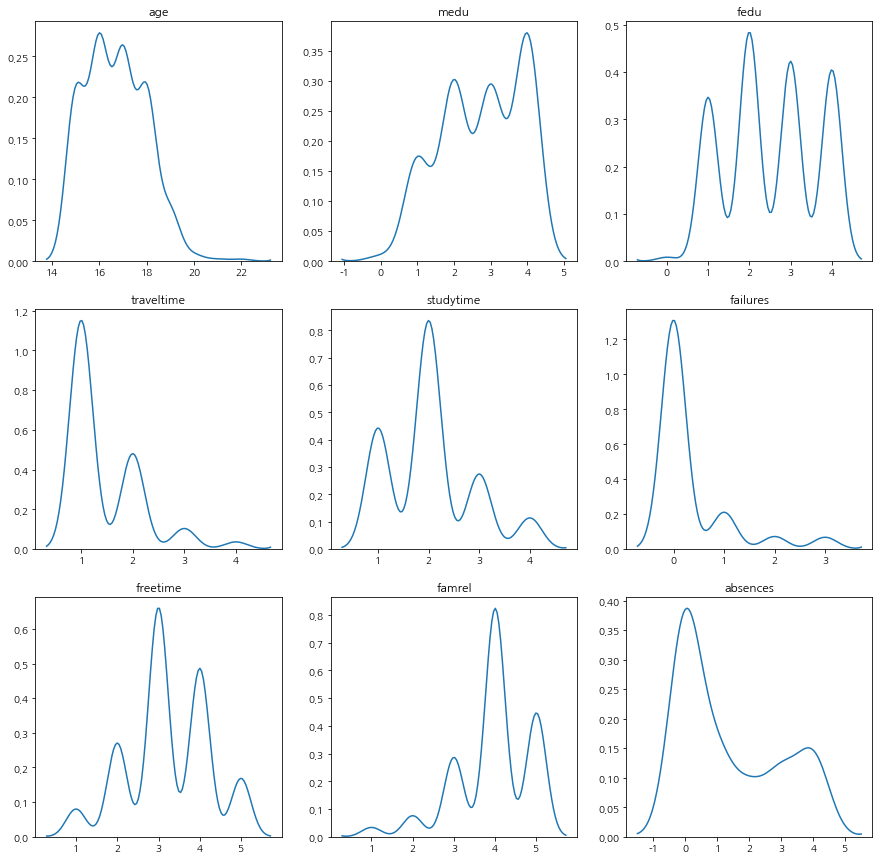

<< 명목형 통계량 >>


,count,unique,top,freq
sex,395,2,F,208
pstatus,395,2,T,354
guardian,395,3,mother,273


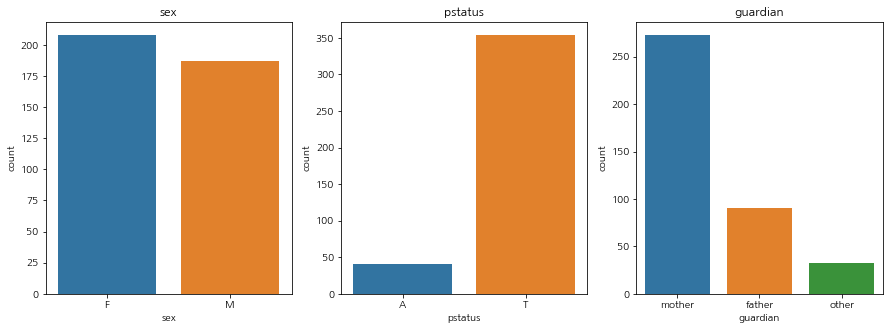

In [18]:
cat_cols = df.select_dtypes(include='object').columns
num_cols = df.select_dtypes(include='number').columns

print("<< 수치형 (명목 순위형 포함) 통계량 >>")
display(df[num_cols].describe().T)

fig, ax = plt.subplots(3, 3, figsize=(15, 15))
for col, ax in zip(num_cols, ax.flatten()):
    sns.kdeplot(data=df[col], legend=False, ax=ax)
    ax.set_title(col)
plt.show()

print("<< 명목형 통계량 >>")
display(df[cat_cols].describe().T)
fig, ax = plt.subplots(1, 3, figsize=(15, 5)) 
for i, col in enumerate(cat_cols):
    sns.countplot(df[col], ax=ax[i])
    ax[i].set_title(col)
plt.show()

- 16세 학생 수가 가장 많으며, 그래프가 왼쪽으로 치우친(양의 왜도) 분포
- 고등교육 받은 어머니 비율이 가장 높으며, 5-9학년 교육을 받은 아버지 비율이 가장 높음
- 학교까지 이동시간이 15분 미만인 학생 수가 많음
- 2-5시간 주간학습시간 비율이 가장 높음
- 낙제를 하지 않은 학생이 대부분
- 방과후 자유시간이 중간(3) 인 학생수가 가장 높음
- 가족관계 질은 다소 높음(4)이 가장 많음
- 결석 횟수가 없는 학생이 대부분임

- 남녀 비율은 여성이 다소 높으나, 대체로 균형
- 부모와 동거중 학생 비율이 압도적으로 높음
- 주 양육자는 어머니인 경우 비율이 압도적임

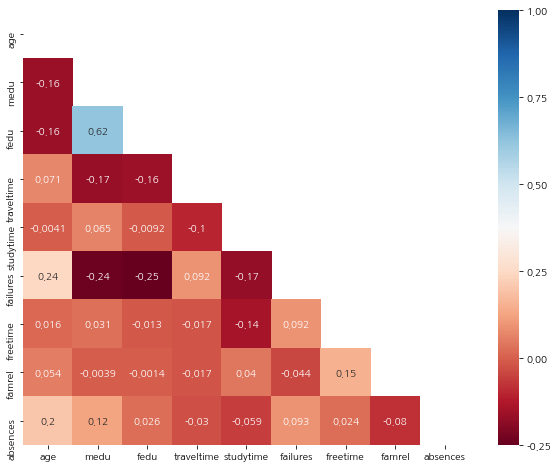

In [22]:
plt.figure(figsize=(10, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype='bool'))
sns.heatmap(corr, mask=mask, annot=True, cmap='RdBu')
plt.show()

수치형(순위형 변수 포함) 변수의 피어슨(선형) 상관관계를 확인했을 때, 부모 간(어머니-아버지) 상관관계를 제외하고는 유의미한 관계는   
식별되지 않았다. 위 상관관계는 변수 간 `1:1 선형 관계만을 고려하기 때문에 1:many 상관관계 확인을 위해 VIF 를 확인한다.

In [23]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
vif['name'] = num_cols
vif['vir'] = [variance_inflation_factor(df[num_cols].values, i) for i in range(len(num_cols))]

display(vif)

,name,vir
0,age,44.304243
1,medu,12.394094
2,fedu,10.613005
3,traveltime,5.443189
4,studytime,7.239047
5,failures,1.408632
6,freetime,11.746996
7,famrel,20.561859
8,absences,1.923648


vif는 다중공선성을 확인하기 편리한 척도이며(1:many 변수 관계) 일반적으로 10 이상이면 다중공선성이 있다고 판단한다.  
5개 변수에서 10 이상의 다중공선성(다중조합형 공선성) 이 식별이 되었기 때문에 차원축소를 고려하는 것이 적합할 것이다.

따라서 PCA를 통해 다중공선성 문제를 해결 후 모델 학습에 활용한다.

다중조합형 공선성: 어떤 변수 X1이 X2, X3, X4와 각각은 약한 상관을 보여도
이 세 개가 함께 조합될 때 X1을 거의 예측할 수 있다면 → VIF는 매우 커짐
다음으로 PCA 모델 구축 후 분산 설명력을 확인한다.
PCA 전 데이터셋 분류, 스케일링을 수행한다.

#### 1-2. 데이터 품질 개선을 위한 방법이 있는지 찾고 데이터셋을 재생성하라 (5점)

위 문제에서 데이터의 다중공선성이 발견되었기 때문에 PCA를 통해 다중공선성을 제거한다.  

- 주성분분석(PCA)을 통한 차원축소
  데이터를 대표하는 새로운 축(주성분)을 생성하고, 변수 데이터를 사영하여 적절한 설명률을 가진 변수 선택
  
주성분은 거리기반 기법이므로 적용 전 스케일링(여기서는 standard scaler)를 적용하며, 모든 기법은 데이터 누수를 방지하기 위해   
train, test set으로 분리 후 적용한다. 

(train/test): (296, 11) (99, 11)


,고윳값,분산설명력,누적분산설명력
0,24.358610,0.250567,0.250567
1,19.324640,0.157703,0.408270
2,18.205101,0.139960,0.548230
3,17.175286,0.124574,0.672804
4,16.527614,0.115356,0.788160
5,14.442443,0.088085,0.876244
6,13.943453,0.082103,0.958347
7,9.931474,0.041653,1.000000


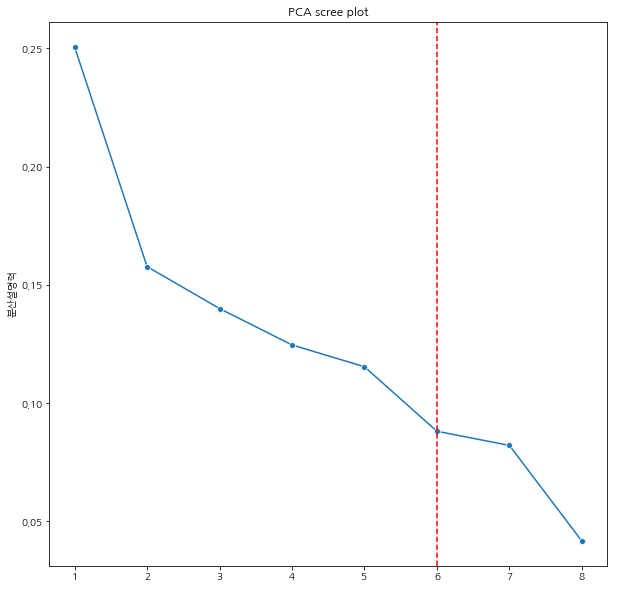

차원축소 후(train/test): (296, 6) (99, 6)


,comp1,comp2,comp3,comp4,comp5,comp6,sex_M,pstatus_T,guardian_mother,guardian_other
0,2.652569,-0.115845,-0.283006,0.101468,0.163065,0.555215,1,1,1,0
1,0.086612,1.325229,-1.408240,1.113674,-0.622899,1.916122,0,1,0,0
2,-1.210298,0.074465,-0.827048,-0.856730,0.166914,1.014988,0,1,1,0
3,-1.149319,-0.283891,0.111107,-0.133108,1.876998,-0.001767,0,1,1,0
4,-0.990522,0.887216,-0.510661,-0.295791,-0.384775,0.385850,0,1,1,0


(296, 10) (99, 10)


In [163]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = df.drop(columns=['absences'])
Y = df['absences']

train_X, test_X, train_Y, test_Y = train_test_split(X, Y, random_state=42, stratify=Y)

print("(train/test):", train_X.shape, test_X.shape)

sc = StandardScaler()

train_X_n = sc.fit_transform(train_X[num_cols[:-1]])
test_X_n = sc.transform(test_X[num_cols[:-1]])

pca = PCA(svd_solver='auto')
train = pca.fit_transform(train_X_n)


rs = pd.DataFrame({'고윳값': pca.singular_values_, 
                  '분산설명력': pca.explained_variance_ratio_, 
                  '누적분산설명력': np.cumsum(pca.explained_variance_ratio_)})


display(rs)

plt.figure(figsize=(10, 10))

sns.lineplot(data=rs, x=rs.index+1, y="분산설명력", marker='o')
plt.title("PCA scree plot")
plt.axvline(x=6, color='r', ls='--')
plt.show()


pca = PCA(n_components=6, svd_solver='auto')
train_X_n = pca.fit_transform(train_X_n)
test_X_n = pca.transform(test_X_n)


print("차원축소 후(train/test):", train_X_n.shape, test_X_n.shape)

train_X_n = pd.DataFrame(train_X_n, columns= ["comp"+ str(i) for i in range(1, train_X_n.shape[1]+1)])
test_X_n = pd.DataFrame(test_X_n, columns= ["comp"+ str(i) for i in range(1, test_X_n.shape[1]+1)])

train_X = pd.concat([train_X_n.reset_index(drop=True), train_X[cat_cols].reset_index(drop=True)], axis=1)
test_X = pd.concat([test_X_n.reset_index(drop=True), test_X[cat_cols].reset_index(drop=True)], axis=1)

#명목형 변수 get dummies

train_X = pd.get_dummies(train_X, columns=cat_cols, drop_first=True)
test_X = pd.get_dummies(test_X, columns=cat_cols, drop_first=True)

display(train_X.head())
print(train_X.shape, test_X.shape)

#### 1-3. 1.2에서 제시한 방법이 데이터 과적합이 된다는 가정하에 어떻게 해결할 수 있을지 2가지 개선안 제시, 각방법들의 장단점 기술하라. (10점)

데이터가 모델에 과적합되었다는 뜻은 train set에 지나치게 모델이 맞춰져서 train set의 성능은 높으나, 학습되지 않은 test set의 성능은  
낮은 것을 말한다. 적절히 예측성능을 보장하면서 일반화된 학습모델로 개선이 필요하다.  

1. 정규화: 비용함수에 가중치를 적용하는 L1(Lasso), L2(Ridge), 복합(엘라스틱넷) 정규화 적용으로 일반화 모델 구현  
  - 간단한 구현, 적용이 가능하나 하이퍼파라미터 튜닝이 어렵고, 성능저하 위험이 있으며 정규화 항 추가로 계산비용 증가  
  
  
2. 조기종료(Early Stopping): 훈련 중 검증(validation) 데이터로 성능을 측정하여, 더 이상 성능의 향상이 유의미하지 않으면  
   학습을 종료하는 방식, 구현이 쉬우며 불필요한 학습에 소요되는 시간을 단축할 수 있으나. 검증 데이터가 필요하고 일시적 성능저하로  
   (local minina를 찾은 경우) 국소 최적해를 찾아 학습이 일찍 종료되어 낮은 성능을 보일 수 있음

#### 2-1. 1-2 데이터셋을 기준으로 random forest, neural network , lightgbm 3가지 방식으로 학교 결석 횟수등급을 예측하는 모델을 만들어라, f1 score로 모델을 평가하라 (5점)

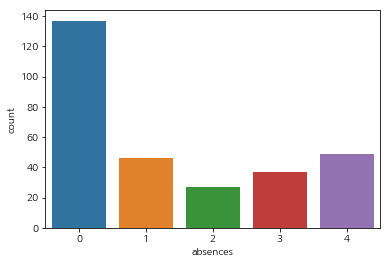

In [164]:
sns.countplot(train_Y)
plt.show()

학교결석횟수는 0~4까지의 순위형 명목변수이다. 이 문제를 multi calss를 예측하는 분류모델로 적합 후 f1 score로 test set을 기준으로  
평가하여 최적의 모델을 선정한다.

- 랜덤포레스트 모델 train set 학습
  - train set 셋 confusion matrix:


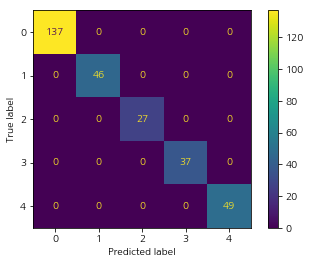

  - test set 셋 confusion matrix:


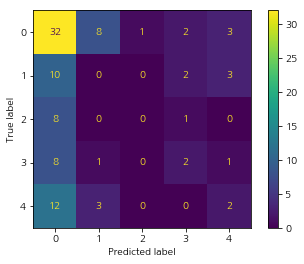

- MLP 모델 train set 학습
  - train set 셋 confusion matrix:


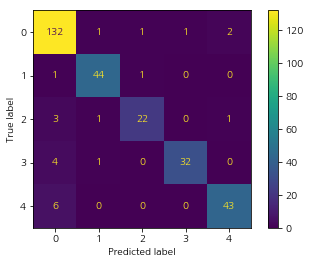

  - test set 셋 confusion matrix:


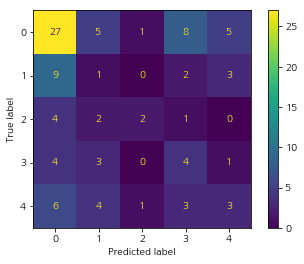

- LGBM 모델 train set 학습
  - train set 셋 confusion matrix:


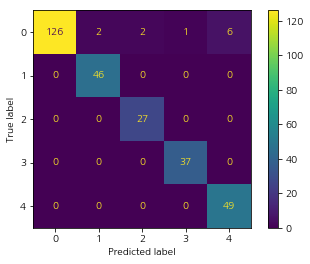

  - test set 셋 confusion matrix:


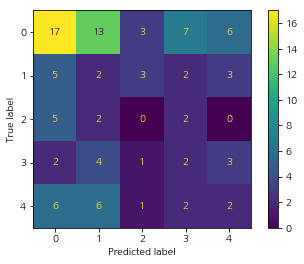

,모델명,data,f1_score
0,랜덤포레스트,train set,1.000000
1,랜덤포레스트,test set,0.183219
2,MLP,train set,0.912279
3,MLP,test set,0.282084
4,LGBM,train set,0.966032
5,LGBM,test set,0.158434


In [165]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import f1_score, classification_report, ConfusionMatrixDisplay, confusion_matrix

rf = RandomForestClassifier(class_weight='balanced', random_state=42)
mlp = MLPClassifier(max_iter=1000, alpha=0.001, random_state=42)
lgbm = LGBMClassifier(class_weight='balanced', random_state=42)

model_list = [rf, mlp, lgbm]
model_name = ['랜덤포레스트', 'MLP', "LGBM"]

dt_list = [("train set", train_X, train_Y), ("test set", test_X, test_Y)] 
rs = pd.DataFrame(columns=['모델명', 'data', 'f1_score'])


for model, name in zip(model_list, model_name):
    print(f"- {name} 모델 train set 학습")
    model.fit(train_X, train_Y) 
    for d_name, x, y in dt_list:
        pred = model.predict(x)
        score = f1_score(y, pred, average='macro')
        rs.loc[len(rs)] = [name, d_name, score]
        print(f"  - {d_name} 셋 confusion matrix:")
        cm = confusion_matrix(y, pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot()
        plt.show()
display(rs)

세 모델 학습결과, 모두 train set의 성능은 높지만 test set의 성능은 낮은 과적합을 보이고 있다.  
confusion matrix를 살펴보면 1~4에 해당하는 소수클래스의 실제 데이터를 majority class인 0으로 오분류한 경우가 많음을 알 수 있다.    

이를 개선하기 위해서는 over sampling 기법인 SMOTE를 적용하거나, 문제를 단순화 하거나(결석과 결석이 아닌 이진분류 문제),  
데이터를 증가시키거나, 모델을 일반화하는 방식 등을 고려할 수 있겠다. 


#### 2-2. hard voting, soft voting에 대한 장단점을 설명하고 2-1의 3가지 모델로 구현하라. 두 방식의 f1-score를 비교하라 (10점)

1. Hard Voting (하드 보팅): 다수결 원칙에 따라 각 분류기의 예측 클래스 레이블을 투표로 결합, 가장 많은 투표를 받은 클래스가 최종 예측값이 됨
- 장점: 구현이 간단하며 직관적, 확률정보가 없는 모델도 사용 가능, 계산비용이 상대적으로 낮음
- 단점: 확률정보를 활용하지 못하며 각 분류기의 확신도를 미고려, 성능이 soft voting보다 상대적으로 낮음


2. Soft Voting (소프트 보팅): 각 분류기의 예측 확률을 평균내어 가장 높은 평균 확률을 가진 클래스를 선택, 확률 정보를 활용하여 더 정교한 결정
- 장점: 확률정보 활용 더 정확한 예측 가능, 각 분류기 확신도 반영, 일반적으로 하드보팅보다 성능이 우수
- 단점: 모든 분류기가 확률을 출력할 수 있어야 함, 계산비용 상대적 높음, 분류기들이 잘 보정되어야 효과적

- 하드보팅 모델 train set 학습
  - train set 셋 confusion matrix:


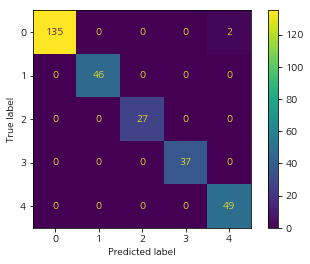

  - test set 셋 confusion matrix:


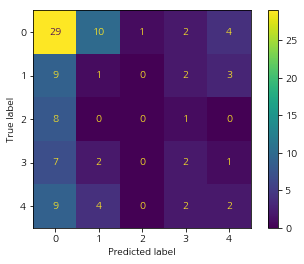

- 소프트보팅 모델 train set 학습
  - train set 셋 confusion matrix:


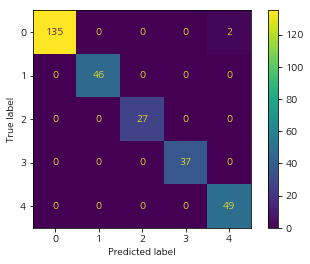

  - test set 셋 confusion matrix:


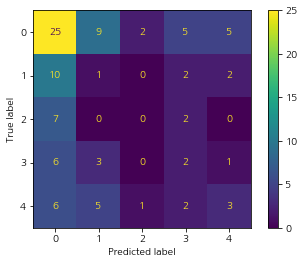

,모델명,data,f1_score
0,하드보팅,train set,0.994529
1,하드보팅,test set,0.187632
2,소프트보팅,train set,0.994529
3,소프트보팅,test set,0.186978


In [167]:
from sklearn.ensemble import VotingClassifier

m1 = RandomForestClassifier(class_weight='balanced', random_state=42)
m2 = MLPClassifier(max_iter=1000, alpha=0.001, random_state=42)
m3 = LGBMClassifier(class_weight='balanced', random_state=42)

hard_v = VotingClassifier(
    estimators=[('rf', m1), ('mlp', m2), ('lgbm', m3)], 
    voting='hard'
)

soft_v = VotingClassifier(
    estimators=[('rf', m1), ('mlp', m2), ('lgbm', m3)],
    voting='soft'
)

model_list = [hard_v, soft_v]
model_name = ['하드보팅', "소프트보팅"]

dt_list = [("train set", train_X, train_Y), ("test set", test_X, test_Y)] 
rs = pd.DataFrame(columns=['모델명', 'data', 'f1_score'])


for model, name in zip(model_list, model_name):
    print(f"- {name} 모델 train set 학습")
    model.fit(train_X, train_Y) 
    for d_name, x, y in dt_list:
        pred = model.predict(x)
        score = f1_score(y, pred, average='macro')
        rs.loc[len(rs)] = [name, d_name, score]
        print(f"  - {d_name} 셋 confusion matrix:")
        cm = confusion_matrix(y, pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot()
        plt.show()
display(rs)

하드보팅과 소프트보팅을 수행한 결과, 소프트보팅의 f1_score 가 더 높게 측정되었다.  
모델 하이퍼파라미터가 최적화된 상태의 모델이 아니기 때문에 성능이 높지는 않았지만, 이전 개별적인 모델을 활용하여  
앙상블 모델을 구축하여 일반화된 모델이 구축된 것을 확인할 수 있다. 

#### 총 5개 모델(RF, NN, LGBM, 하드보팅, 소프트보팅) 중 실시간 온라인 시스템에 가장 적합한 모델과 선정이유를 객관적으로 제시하라 (5점)

- 최적의 모델: MLP
  - 테스트 F1 최고(0.2428)로 일관된 예측 성능
  - 단일 경량 신경망 구조로 추론 지연시간 최소화
  - 배포·운영 난이도가 낮아 실시간 환경에 적합
  - 하이퍼파라미터(은닉층, 유닛 수) 조정으로 지연시간 vs 성능 추가 최적화 가능
  
  
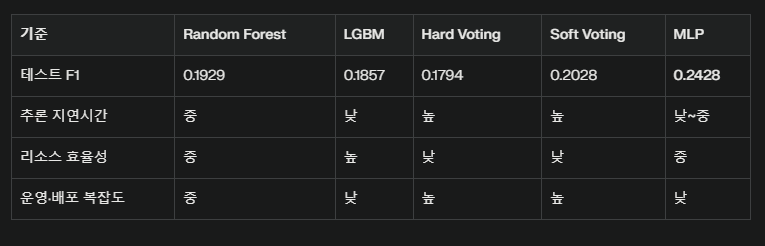

MLP가 실시간 온라인 시스템에 가장 적합함.   
테스트 F1이 가장 높아 예측 품질이 우수하고, 단일 경량 신경망의 추론 속도·운영 편의성 면에서도 최적의 선택임

#### 3-1. 적정 모델과 선정 및 모델링 과정에서 추가적으로 고려해볼 만한 사항은? (5점)

해당 데이터의 레이블은 멀티 클래스이며, 불균형 데이터이다.  
결석, 결석x로 파생변수를 레이블로 재생성하여 활용함으로써 문제를 단순화시키며, 데이터의 불균형 정도를 낮출 수 있다.  

모델의 과적합을 해결하기 위한 방안으로
1. 추가적인 데이터의 확보 및 학습
2. 모델의 단순화(드롭아웃, 정규화 등)

등의 방법을 적용할 수 있을 것이다. 

#### 3-2. 모델을 학교 시스템에 적용하여 활용하려한다. 모델 적용 및 운영과정에서 고려해볼 만한 사항? (5점)

랜덤 포레스트 모델 기준으로 어느 feature가 모델학습결과에 큰 영향을 주는지 찾아보고, 운영과정에 이를 적용한다.

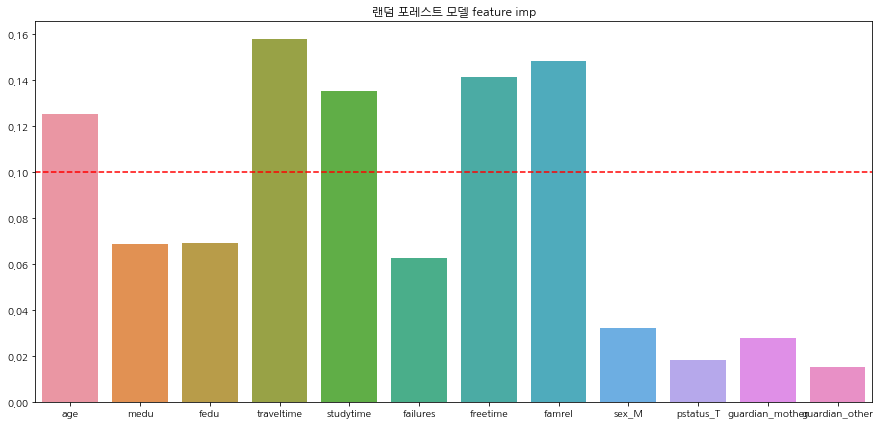

In [208]:
pca_param = pca.components_ #pca 계수 6차원
rf_imp = rf.feature_importances_ # 범주형 포함 10

origin_imp = np.sum((pca_param**2) * rf_imp[:6][:, np.newaxis], axis=0)
origin_imp = np.append(origin_imp, rf_imp[6:])

f_name =num_cols[:-1].tolist() +train_X.columns[6:].tolist()

plt.figure(figsize=(15, 7))
sns.barplot(x=f_name, y=origin_imp)
plt.title('랜덤 포레스트 모델 feature imp')
plt.axhline(y=0.1, color='r', ls='--')
plt.show()

통학시간, 공부시간, 휴식시간, famel, age가 임의의 임계치인 0.1을 초과한다. 이 변수들의 추이를 확인한다. 

만약 통학시간이 짧을수록 출결이 좋다면, 거리가 먼 곳에 위치한 학생들에게 통학버스 서비스를 제공하는 등의 방법이 있을 것이다.

## 4. 생존 분석

#### 4-1. Kaplan Meier 방법 사용 생존분석 수행. 회사부품별 25, 35, 45 개월에서의 생존 확률 (소숫점 3자리 ,5점)

In [213]:
df3 = pd.read_csv('https://raw.githubusercontent.com/qiwerr1004/ADP_go/main/28/problem3.csv')

df3.head()

,time,status,company
0,8,1,X
1,10,1,X
2,8,0,X
3,12,1,X
4,20,1,X



< X>
25 개월 후 생존확률: 64.167 % / 불량률: 35.833 %
35 개월 후 생존확률: 55.000 % / 불량률: 45.000 %
45 개월 후 생존확률: 55.000 % / 불량률: 45.000 %

< Y>
25 개월 후 생존확률: 56.250 % / 불량률: 43.750 %
35 개월 후 생존확률: 28.125 % / 불량률: 71.875 %
45 개월 후 생존확률: 18.750 % / 불량률: 81.250 %


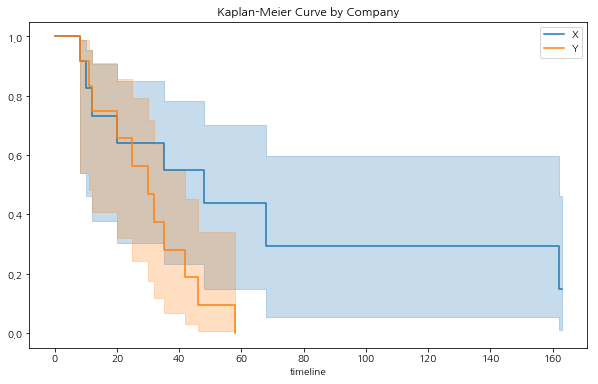

In [217]:
from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()
plt.figure(figsize=(10, 6))

for com in df3['company'].unique():
    sub_com = df3[df3.company == com]
    kmf.fit(durations = sub_com['time'], event_observed=sub_com['status'], label=com)
    print(f"\n< {com}>")
    
    for t in [25, 35, 45]:
        s = kmf.survival_function_at_times(t).values[0]
        f_rate = 1 - s
        print(f"{t} 개월 후 생존확률: {s*100:.3f} % / 불량률: {f_rate*100:.3f} %")
    kmf.plot_survival_function()
plt.title('Kaplan-Meier Curve by Company')
plt.show()

< X>
- 25 개월 후 생존확률: 64.167 % / 불량률: 35.833 %
- 35 개월 후 생존확률: 55.000 % / 불량률: 45.000 %
- 45 개월 후 생존확률: 55.000 % / 불량률: 45.000 %

< Y>
- 25 개월 후 생존확률: 56.250 % / 불량률: 43.750 %
- 35 개월 후 생존확률: 28.125 % / 불량률: 71.875 %
- 45 개월 후 생존확률: 18.750 % / 불량률: 81.250 %

전 기간에 걸쳐 X회사의 생존확률(불량률은 더 낮음)이 더 높다.  
또한 시간이 지남에 따라서도 생존확률은 천천히 감소한다.

#### 4-2. 두 회사간 생존시간 차이를 log-rank 방식으로 검정하시오. 가설설정, 통계량, 귀무가설 기각여부 판단(10점)

로그 순위법은 두 생존 곡선이 차이가 있는지 검정하는 비모수적 방법  
survdiff 함수에 구현되어 있으며, 유의 수준 0.05에서 검정을 실시하는 방법

- 귀무: 두 생존함수는 동일하다. 
- 대립: 두 생존함수는 같지 않다.

In [224]:
from lifelines.statistics import logrank_test

com_X = df3[df3.company == 'X']
com_Y = df3[df3.company == 'Y']

rt = logrank_test(com_X['time'], com_Y['time'], 
                 event_observed_A=com_X['status'], 
                 event_observed_B=com_Y['status'])



p, stat = rt.p_value, rt.test_statistic

print(f"통계량: {stat:.3f}")
print(f"p-value: {p:.3f}")
print(f"유의수준 5% 하에서 귀무가설을", "기각" if p < 0.05 else "기각x")

통계량: 3.643
p-value: 0.056
유의수준 5% 하에서 귀무가설을 기각x


- 통계량: 3.643
- p-value: 0.056
유의수준 5% 하에서 귀무가설을 기각할 수 없으므로 두 생존함수는 동일하다고 볼 수 있다.(생존확률 차이가 통계적으로 유의하지 않다.)

## 5.
- data형식
    - 한 유저가 시식 전 물건 구매의사 유,무와 시식 후 구매의사 유,무에 대한 응답을 나타낸 데이터

   

In [233]:
import pandas as pd
df = pd.read_csv('https://raw.githubusercontent.com/Datamanim/datarepo/main/adp/28/p5_.csv ')
df.head()

df[['시식전', '시식후']] = df['data'].str.extract(r'시식전_(유|무)__시식후_(유|무)')
df = df.replace({'유': 1, '무': 0})

tb = pd.crosstab(df['시식전'], df['시식후'])

#### 5-1. 시식여부가 구매의사에 영향을 주는지 가설을 설정하시오(5점)

해당문제는 한 집단의 이진 조건 분류 결과간의 비율 차이가 통계적으로 유의한지 판단하는 맥니머 검정 문제이다. 비모수 검정 방식이며 카이제곱 통계량을 사용한다. 

- 귀무: 시식 전 후 구매의사 변화가 없다. 
- 대립: 시식 전후 구매의사 변화가 있다. 


#### 5-2. 검정하고 결과를 분석하시오(5점)

In [234]:
from statsmodels.stats.contingency_tables import mcnemar

rs = mcnemar(tb, exact=False, correction=False)

print(f"통계량: {rs.statistic}")
print(f"p-values: {rs.pvalue:.3f}")

통계량: 3.24
p-values: 0.072


유의수준 5% 하에서 p-value가 0.072로 크므로 귀무가설을 기각할 수 없다.  
따라서 시식 전후 구매의사 변화가 없다. 

## 6.
#### 6-1. A,B 지역 학생의 점수에 차이가 있는지 가설을 설정하고 정하시오 (10점)

In [236]:
import pandas as pd
df = pd.read_csv('https://raw.githubusercontent.com/Datamanim/datarepo/main/adp/28/p6.csv')
df.head()

,score,school_name,ID
0,91.0,A,1
1,NaN,A,2
2,NaN,A,3
3,NaN,A,4
4,NaN,A,5


In [238]:
df = df.dropna() #결측치 8개 삭제
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 28 entries, 0 to 35
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   score        28 non-null     float64
 1   school_name  28 non-null     object 
 2   ID           28 non-null     int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 896.0+ bytes


In [239]:
df.school_name.value_counts()

B    18
A    10
Name: school_name, dtype: int64

결측치를 제외한 후 두 집단의 크기를 확인했을 때 18, 10개로 소규모 데이터이다. 데이터의 수가 적어서 모수기법(중심극한의 정리를 통해 모수추정 시 최소 30개의 데이터가 있어야 함)을 적용하기 어려우므로 비모수기법인 KS test를 통해 두 집단의 분포검정을 실시

<가설설정>
- 귀무: 두 학교의 점수 분포는 같다.
- 대립: 두 학교의 점수 분포는 차이가 있다.

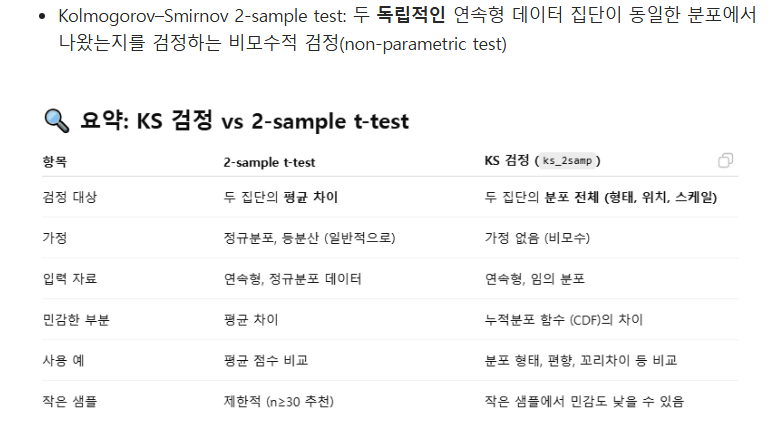

In [241]:
A = df[df['school_name'] == 'A']['score']
B = df[df['school_name'] == 'B']['score']

from scipy.stats import ks_2samp

stat, p = ks_2samp(A, B)

print(f"KS 검정 통계량: {stat:.3f}")
print(f"p-value: {p:.3f}")

KS 검정 통계량: 0.500
p-value: 0.055


유의수준 5% 하에서 p-value는 0.49로 귀무가설을 기각할 수 없다. 따라서 두 학교의 점수 분포는 같다.

## 7.
- 데이터 출처 : https://www.kaggle.com/datasets/hangawqadir/erbil-heart-disease-dataset
- 데이터 url : https://raw.githubusercontent.com/Datamanim/datarepo/main/adp/28/p7.csv
- 연령, 몸무게,콜레스테롤 수치 데이터

In [242]:
import pandas as pd
df = pd.read_csv('https://raw.githubusercontent.com/Datamanim/datarepo/main/adp/28/p7.csv')
df.head()

,age,Cholesterol,weight
0,65,69.0,111.0
1,54,117.0,81.0
2,61,86.2,72.0
3,57,76.0,78.0
4,62,160.0,61.0


In [243]:
df.isna().sum()

age            0
Cholesterol    0
weight         0
dtype: int64

#### 7-1. 몸무게를 제어한다고 생각하고, 나이와 콜레스테롤 상관계수 및 유의확률 구하라(10점)

부분상관 문제이다.
제3변수(weight)의 영향을 제거한 상태에서, 나이와 콜레스테롤 사이의 상관관계를 파악

<가설>
- H0: 몸무게를 제어했을 때, 나이와 콜레스테롤의 상관계수는 0이다.
- H1: 몸무게를 제어했을 때, 나이와 콜레스테롤 상관계수는 0이 아니다.

In [244]:
import pingouin as pg
rs = pg.partial_corr(data=df, x='age', y='Cholesterol', covar='weight')
display(rs)

,n,r,CI95%,r2,adj_r2,p-val,BF10,power
pearson,333,-0.134317,"[-0.24, -0.03]",0.018041,0.01209,0.014169,1.372,0.690805


편상관계수(r)는 -0.134317, p-value는 0.014169이다.

#### 7-2. 상관계수를 유의수준 0.05하에서 검정하라 (5점)

유의수준 5%하에서 0.014169로 0.05보다 작으므로 귀무가설을 기각할 수 있다.  
따라서 몸무게를 제어했을 때, 나이와 콜레스테롤 상관계수는 0이 아니다.라는 대립가설은 통계적으로 유의하다고 할 수 있다.